In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image

In [2]:
DATASET_PATH = "../datasets/cleaned"

IMG_SIZE = (224, 224)
MAX_IMAGES = 500  # tu peux augmenter plus tard
N_CLUSTERS = 5

In [3]:
files = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith(".jpg")]

files = files[:MAX_IMAGES]

images = []
paths = []

for file in tqdm(files):
    
    img_path = os.path.join(DATASET_PATH, file)

    try:
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img = image.img_to_array(img)

        images.append(img)
        paths.append(img_path)

    except:
        continue

images = np.array(images)

print("Images chargées :", images.shape)

100%|██████████| 500/500 [00:01<00:00, 374.23it/s]


Images chargées : (500, 224, 224, 3)


In [4]:
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

images = preprocess_input(images)

features = model.predict(images)

print("Features shape :", features.shape)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)

labels = kmeans.fit_predict(features)

print("Clustering terminé")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step
Features shape : (500, 2048)
Clustering terminé


c:\Users\sonia\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


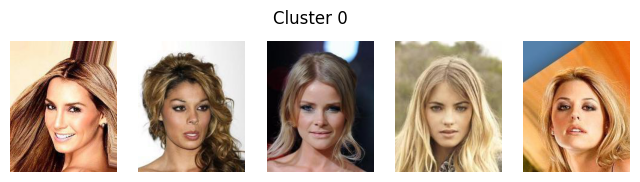

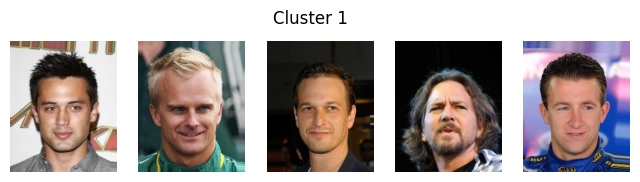

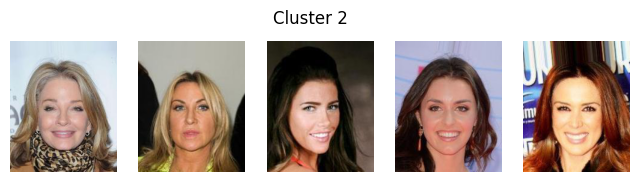

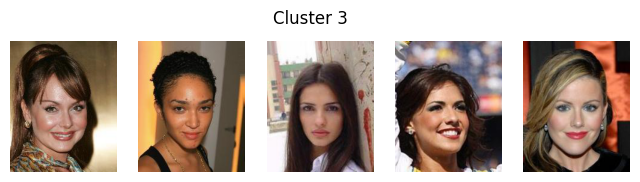

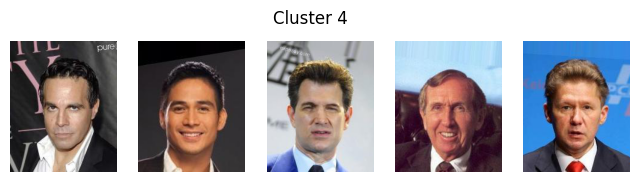

In [5]:
for cluster in range(N_CLUSTERS):

    idx = np.where(labels == cluster)[0][:5]

    plt.figure(figsize=(8,2))

    for i, j in enumerate(idx):

        img = Image.open(paths[j])

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Cluster {cluster}")
    plt.show()

### interprétation 

In [6]:
cluster_names = {
    0: "Style sophistiqué",
    1: "Style masculin classique",
    2: "Style naturel",
    3: "Style élégant naturel",
    4: "Style masculin professionnel"
}

recommendations = {
    0: "Maquillage prononcé, couleurs chaudes",
    1: "Tenue formelle, coupe classique",
    2: "Maquillage léger, tons neutres",
    3: "Look soigné, maquillage équilibré",
    4: "Style professionnel, tenue formelle"
}